In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import Subset
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import math
from models.unet import UNet
from utils import strided_ddim_sample, check_posterior_logic, verify_training_inputs, check_noise_correlation, visualise_loader, make_beta_schedule, periodic_sample_grids, ancestral_sample, plot_ancestral_samples, plot_sampling_norms
from diffusion.diffusion import DiffusionProcess
from models.mnistfe import MNISTFeatureExtractor
from scipy.linalg import sqrtm
from sklearn.metrics.pairwise import polynomial_kernel

In [25]:
EPOCHS = 50
L = 1000
NUM_EVAL_SAMPLES = 10000
BATCH = 128

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [26]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = data.DataLoader(train_dataset, batch_size=BATCH, shuffle=True, num_workers=4)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = data.DataLoader(test_dataset, batch_size=BATCH, shuffle=False, num_workers=4)

In [27]:
model = UNet()
model.load_state_dict(torch.load("/kaggle/input/datasets/qasimayub/ddpmmodel/model.pth", map_location=device))
model = model.to(device)
model.eval()

diff = DiffusionProcess(1000, device)

# 64 Sample Grid

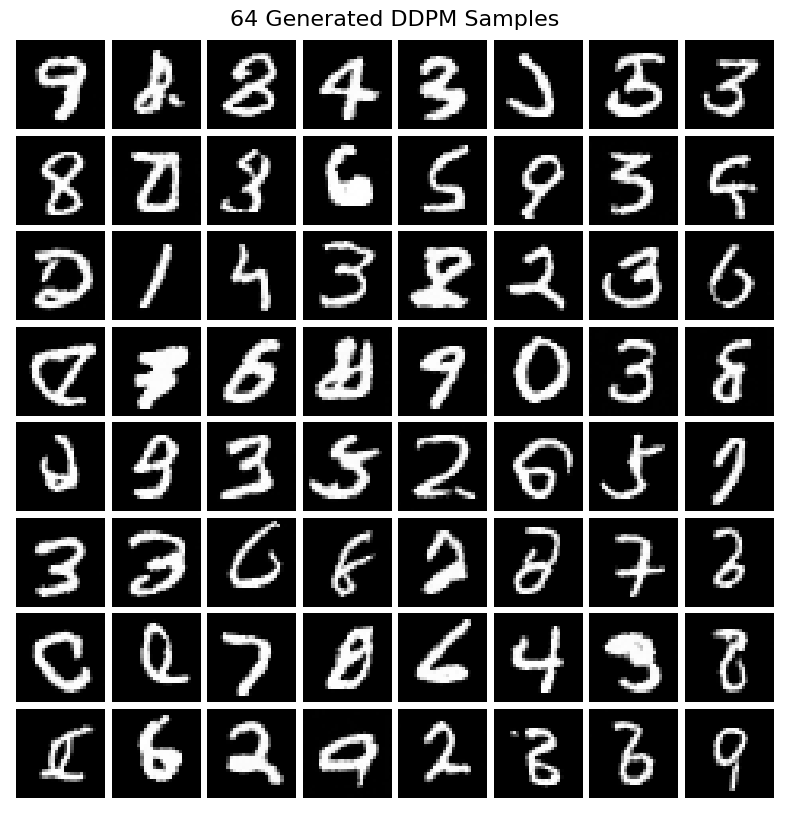

In [28]:
final_xi, intermediates, norms = ancestral_sample(model, diff, count=64, device=device)

final_xi = (final_xi + 1.0) / 2.0
final_xi = final_xi.clamp(0, 1)

grid = torchvision.utils.make_grid(final_xi, nrow=8, padding=2, pad_value=1.0)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).cpu().numpy())
plt.axis("off")
plt.title("64 Generated DDPM Samples", fontsize=16)
plt.show()

# Denoising Trajectories

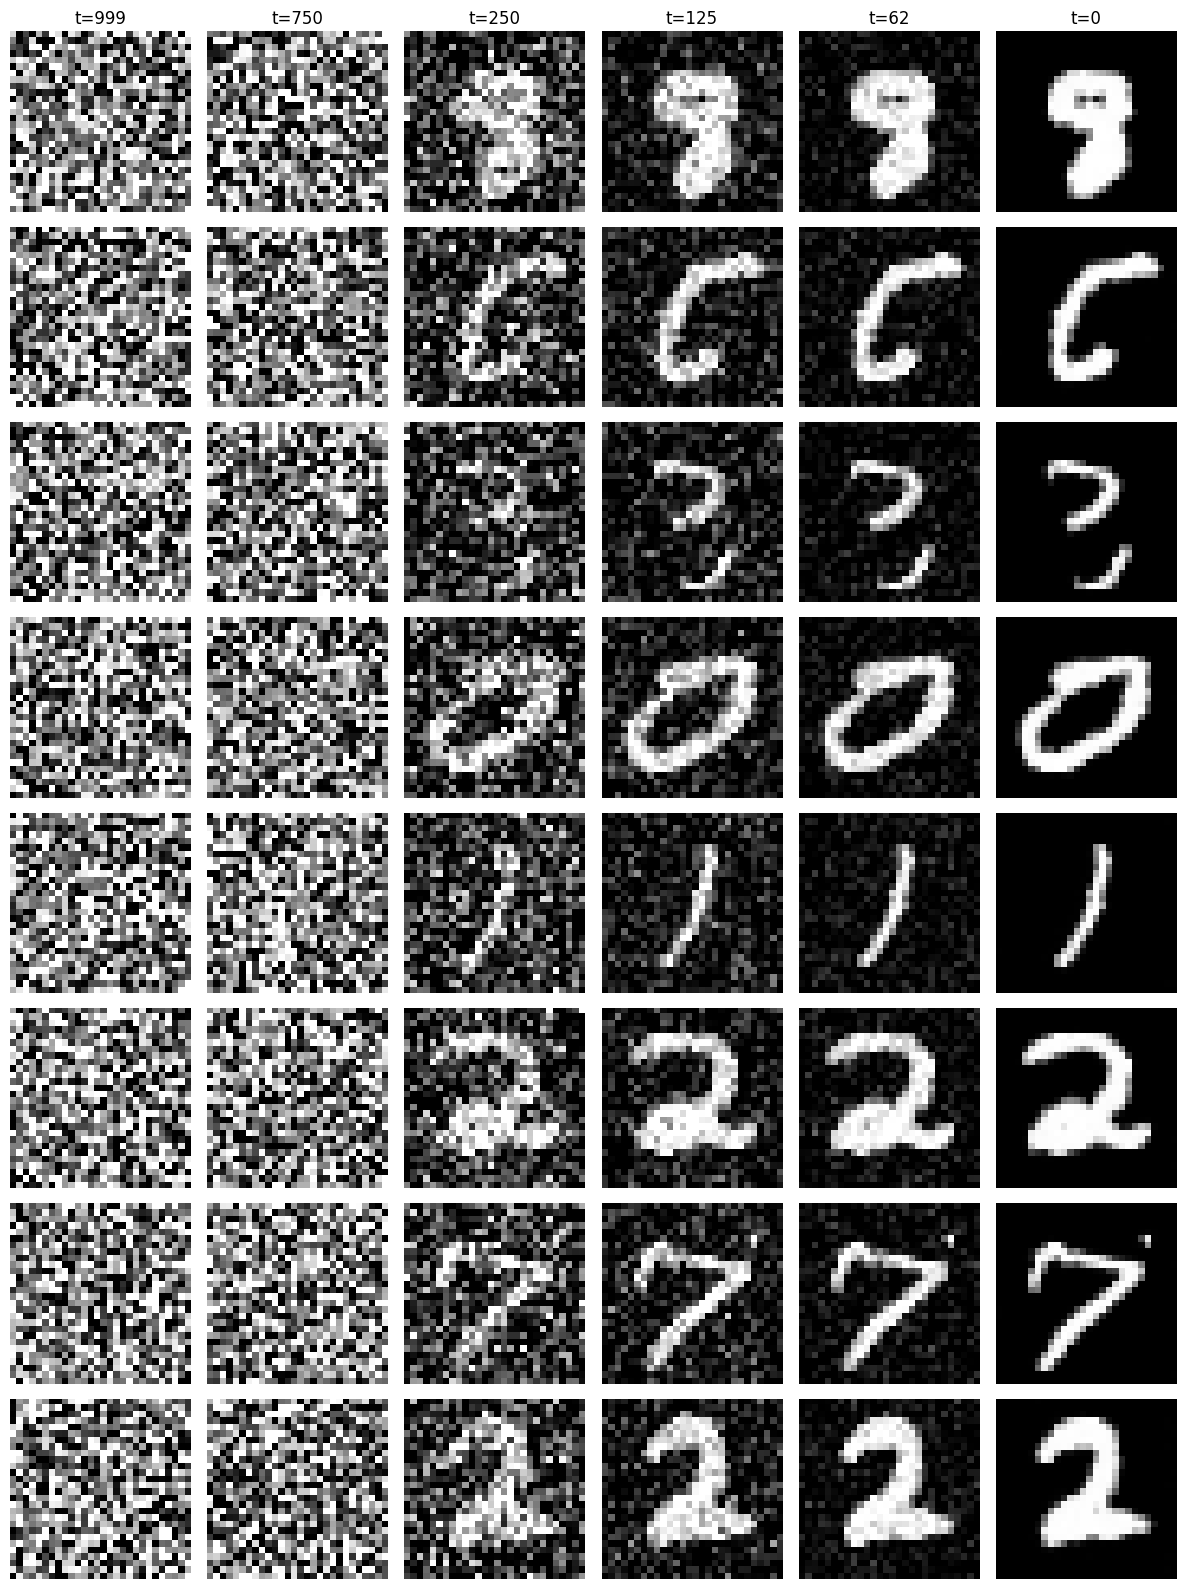

In [29]:
final_xi, intermediates, norms = ancestral_sample(model, diff, count=8, device=device)
plot_ancestral_samples(intermediates, count=8)

# Quantitative Evaluation

In [30]:
classifier = MNISTFeatureExtractor()
classifier.load_state_dict(torch.load("/kaggle/input/datasets/qasimayub/mnistmodel/mnist_classifier.pth", map_location=device))
classifier.to(device)

MNISTFeatureExtractor(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [31]:
real_features = []
with torch.no_grad():
    for imgs, _ in test_loader:
        imgs = imgs.to(device)
        _, feats = classifier(imgs)
        real_features.append(feats.cpu().numpy())
        if sum(len(b) for b in real_features) >= NUM_EVAL_SAMPLES:
            break
real_features = np.concatenate(real_features, axis=0)[:NUM_EVAL_SAMPLES]

fake_features = []
all_fake_images = []
preds = []
batch_size = 125
with torch.no_grad():
    for _ in range(0, NUM_EVAL_SAMPLES, batch_size):
        count = min(batch_size, NUM_EVAL_SAMPLES - _)
        fake_imgs = strided_ddim_sample(model, diff, count, device, stride=10)
        pred, feats = classifier(fake_imgs)
        preds.append(pred.cpu().numpy())
        fake_features.append(feats.cpu().numpy())
        all_fake_images.append(fake_imgs.cpu().numpy())
        torch.cuda.empty_cache()
fake_features = np.concatenate(fake_features, axis=0)
all_fake_images = np.concatenate(all_fake_images, axis=0)
preds = np.concatenate(preds, axis=0)

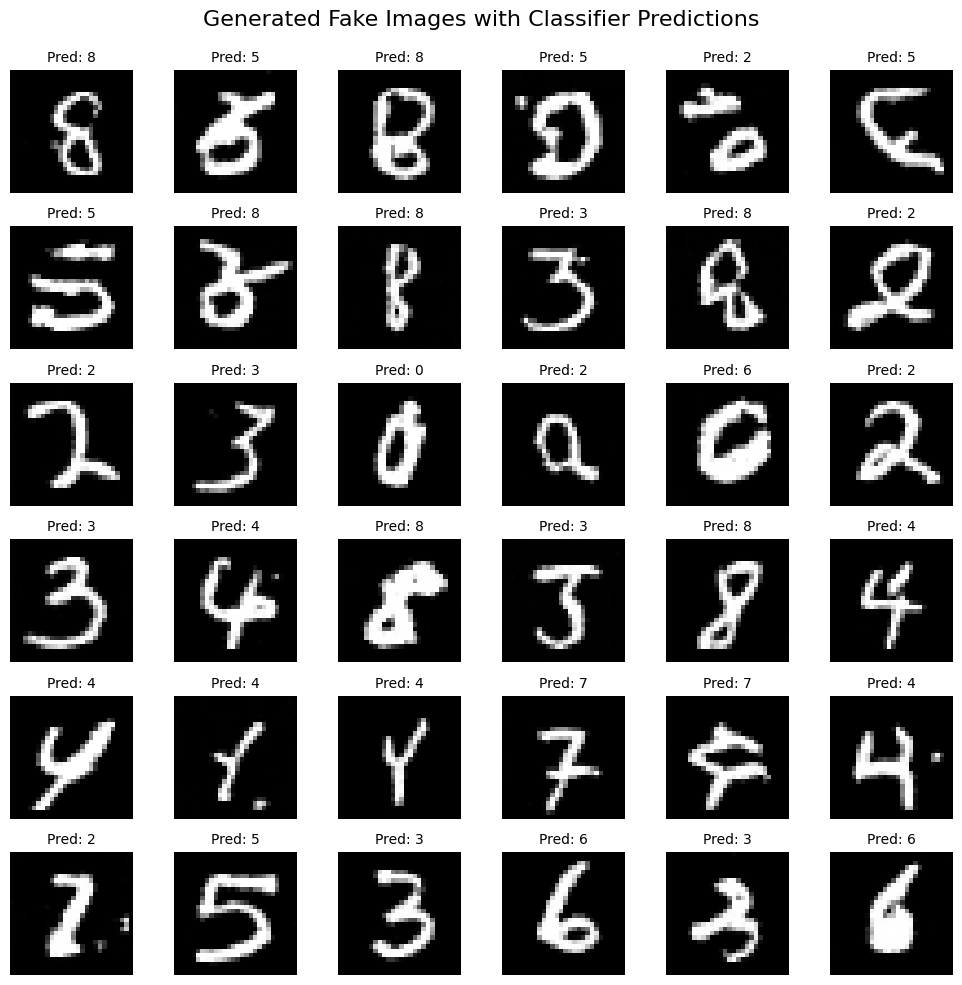

In [32]:
predicted_classes = np.argmax(preds, axis=1)
all_fake_images = (all_fake_images + 1.0) / 2.0
all_fake_images = np.clip(all_fake_images, 0, 1)

random_indices = np.random.choice(NUM_EVAL_SAMPLES, 36, replace=False)
fig, axes = plt.subplots(6, 6, figsize=(10, 10))
fig.suptitle("Generated Fake Images with Classifier Predictions", fontsize=16)

for i, ax in enumerate(axes.flatten()):
    idx = random_indices[i]
    img = all_fake_images[idx].squeeze() 
    label = predicted_classes[idx]
    
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Pred: {label}", fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()

In [37]:
def calculate_fid(act1, act2):
    """Calculates the Frechet Inception Distance."""
    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)
    
    ssdiff = np.sum((mu1 - mu2)**2.0)
    covmean = sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
        
    fid = ssdiff + np.trace(sigma1 + sigma2 - 2.0 * covmean)
    return fid

def calculate_kid(act1, act2, degree=3):
    """Calculates the Kernel Inception Distance using a polynomial kernel."""
    # Scale gamma appropriately for the feature dimension (128)
    gamma = 1.0 / act1.shape[1] 
    
    K_XX = polynomial_kernel(act1, act1, degree=degree, gamma=gamma, coef0=1)
    K_YY = polynomial_kernel(act2, act2, degree=degree, gamma=gamma, coef0=1)
    K_XY = polynomial_kernel(act1, act2, degree=degree, gamma=gamma, coef0=1)
    
    m, n = act1.shape[0], act2.shape[0]
    
    # Remove diagonal elements for unbiased intra-group estimation
    np.fill_diagonal(K_XX, 0)
    np.fill_diagonal(K_YY, 0)
    
    kid = (K_XX.sum() / (m * (m - 1))) + (K_YY.sum() / (n * (n - 1))) - (2 * K_XY.mean())
    return kid

dataset_fid = calculate_fid(real_features, fake_features)
dataset_kid = calculate_kid(real_features, fake_features)

print(f"Dataset-FID Score: {dataset_fid:.4f}")
print(f"Dataset-KID Score: {dataset_kid:.5f}")

/tmp/ipykernel_55/1915275156.py:7: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1.dot(sigma2))


Dataset-FID Score: 82.2057
Dataset-KID Score: 115.94971


# Overfitting test

In [34]:
train_features = []
with torch.no_grad():
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        _, feats = classifier(imgs)
        train_features.append(feats.cpu().numpy())
        if sum(len(b) for b in train_features) >= NUM_EVAL_SAMPLES:
            break
train_features = np.concatenate(train_features, axis=0)[:NUM_EVAL_SAMPLES]

train_dataset_fid = calculate_fid(train_features, fake_features)
train_dataset_kid = calculate_kid(train_features, fake_features)

print(f"Dataset-FID Score: {dataset_fid:.4f} | Train-FID Score: {train_dataset_fid:.4f}")
print(f"Dataset-KID Score: {dataset_kid:.5f} | Train-KID Score: {train_dataset_kid:.5f}")

/tmp/ipykernel_55/1915275156.py:7: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = sqrtm(sigma1.dot(sigma2))


Dataset-FID Score: 82.2057 | Train-FID Score: 80.2769
Dataset-KID Score: 115.94971 | Train-KID Score: 112.95605


# NLL

In [ ]:
def discretized_gaussian_nll(x, means, logvar):
    """
    Computes the discretized Gaussian negative log-likelihood.
    Assumes image data is in the range [-1, 1].
    """
    # Convert log-variance to standard deviation
    std = torch.exp(0.5 * logvar)
    
    # Calculate the CDF bounds for a pixel bin
    # Since data is scaled from [0, 255] to [-1, 1], the bin width is 2/255.
    # Therefore, the radius around each pixel value is 1/255.
    plus_in = (x - means + 1.0 / 255.0) / std
    min_in = (x - means - 1.0 / 255.0) / std
    
    # Calculate standard normal CDF using the error function
    cdf_plus = 0.5 * (1.0 + torch.erf(plus_in / math.sqrt(2.0)))
    cdf_min = 0.5 * (1.0 + torch.erf(min_in / math.sqrt(2.0)))
    
    # Calculate probability mass for each bin
    cdf_delta = cdf_plus - cdf_min
    
    # Handle edge cases where pixel values are at the extreme -1 or 1 bounds
    log_probs = torch.where(
        x < -0.999, 
        torch.log(cdf_plus.clamp(min=1e-12)),
        torch.where(
            x > 0.999, 
            torch.log((1.0 - cdf_min).clamp(min=1e-12)),
            torch.log(cdf_delta.clamp(min=1e-12))
        )
    )
    
    return -log_probs  # Return Negative Log-Likelihood

def kl_divergence_gaussians(mean1, logvar1, mean2, logvar2):
    """
    Calculates the KL divergence between two diagonal Gaussians.
    """
    return 0.5 * (
        -1.0 
        + logvar2 - logvar1 
        + torch.exp(logvar1 - logvar2) 
        + ((mean1 - mean2) ** 2) * torch.exp(-logvar2)
    )

def compute_elbo_bpd(model, x_0, diff, device):
    """
    Computes the upper bound on NLL (ELBO) in bits-per-dimension.
    Tailored for the 0-indexed DiffusionProcess class.
    """
    B, C, H, W = x_0.shape
    D = C * H * W
    L = diff.L
    
    total_elbo = torch.zeros(B, device=device)

    # Prior Loss L_T
    # At index L-1 (Corresponds to final timestep T)
    t_T = torch.full((B,), L - 1, device=device, dtype=torch.long)
    alpha_bar_T = diff.extract(diff.alphas_cumprod, t_T, x_0.shape)
    
    q_mean_T = torch.sqrt(alpha_bar_T) * x_0
    q_logvar_T = torch.log(1.0 - alpha_bar_T + 1e-10) # 1e-10 prevents log(0)
    
    p_mean_T = torch.zeros_like(x_0)
    p_logvar_T = torch.zeros_like(x_0) # Standard normal logvar is 0
    
    prior_kl = kl_divergence_gaussians(q_mean_T, q_logvar_T, p_mean_T, p_logvar_T)
    total_elbo += prior_kl.view(B, -1).sum(dim=1)

    # Diffusion KL Terms
    # Indices t from 1 to L-1 (Corresponds to timesteps 2 to T)
    for t in range(1, L):
        t_tensor = torch.full((B,), t, device=device, dtype=torch.long)
        x_t = diff.q_sample(x_0, t_tensor)
        q_mean, q_var = diff.q_posterior_mean_var(x_0, x_t, t_tensor)
        q_logvar = torch.log(q_var.clamp(min=1e-20))
        
        eps_hat = model(x_t, t_tensor) 
        model_mean = diff.p_mean_from_eps(x_t, t_tensor, eps_hat)
        
        model_var = diff.extract(diff.posterior_variance, t_tensor, x_t.shape)
        model_logvar = torch.log(model_var.clamp(min=1e-20))
        
        kl_term = kl_divergence_gaussians(q_mean, q_logvar, model_mean, model_logvar)
        total_elbo += kl_term.view(B, -1).sum(dim=1)

    # Reconstruction Term L_0
    # At index t=0 (Corresponds to timestep 1)
    t_0 = torch.zeros((B,), device=device, dtype=torch.long)

    x_1 = diff.q_sample(x_0, t_0)

    eps_hat_0 = model(x_1, t_0)
    model_mean_0 = diff.p_mean_from_eps(x_1, t_0, eps_hat_0)

    model_var_0 = diff.extract(diff.betas, t_0, x_0.shape)
    model_logvar_0 = torch.log(model_var_0.clamp(min=1e-20))

    recon_loss = discretized_gaussian_nll(x_0, model_mean_0, model_logvar_0)
    total_elbo += recon_loss.view(B, -1).sum(dim=1)

    bpd = total_elbo / (D * math.log(2.0))
    
    return bpd.mean()

In [39]:
print("Calculating Average Bits-per-Dimension (BPD) on Test Set...")

total_bpd = 0.0
num_batches = 0

model.eval()
with torch.no_grad():
    for imgs, _ in tqdm(test_loader):
        imgs = imgs.to(device)
        batch_bpd = compute_elbo_bpd(model, imgs, diff, device)
        
        total_bpd += batch_bpd.item()
        num_batches += 1
        if num_batches % 10 == 0:
            print(f"Processed {num_batches} batches. Current Avg BPD: {total_bpd / num_batches:.4f}")

avg_bpd = total_bpd / num_batches

print(f"Final Test BPD (Upper Bound on NLL): {avg_bpd:.4f}")

Calculating Average Bits-per-Dimension (BPD) on Test Set...


 13%|█▎        | 10/79 [01:06<07:37,  6.63s/it]

Processed 10 batches. Current Avg BPD: 1.7850


 25%|██▌       | 20/79 [02:12<06:30,  6.63s/it]

Processed 20 batches. Current Avg BPD: 1.7913


...

Processed 60 batches. Current Avg BPD: 1.8052


 89%|████████▊ | 70/79 [07:43<00:59,  6.62s/it]

Processed 70 batches. Current Avg BPD: 1.8125


100%|██████████| 79/79 [08:40<00:00,  6.58s/it]

Final Test BPD (Upper Bound on NLL): 1.8172
